In [246]:
import numpy as np 
import matplotlib.pyplot as plt
import importlib
import plant
import madgwick_filter
importlib.reload (madgwick_filter)
importlib.reload (plant)
from plant import w2b_rotation
from madgwick_filter import MadgwickMARG

# Generate input

In [247]:
dt = 0.01
t = np.arange (0, 10, dt)

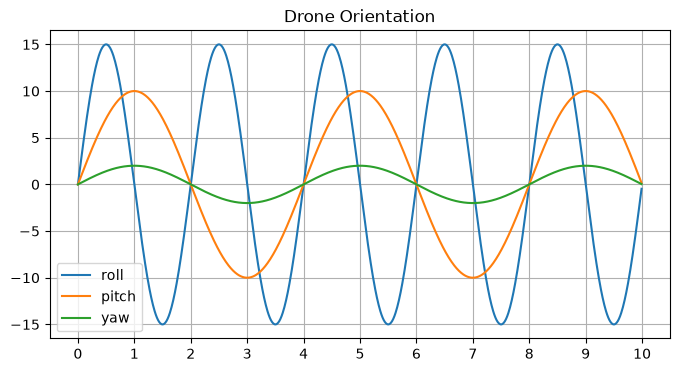

In [248]:
real_roll = np.deg2rad(15) * np.sin (np.pi *t) 
real_pitch = np.deg2rad(10) * np.sin(0.5*np.pi * t)
real_yaw = np.deg2rad(2) * np.sin(0.5 * np.pi * t)

plt.figure(figsize=(8,4))
plt.plot (t, np.rad2deg(real_roll), label = 'roll')
plt.plot (t, np.rad2deg(real_pitch), label = 'pitch')
plt.plot (t, np.rad2deg(real_yaw), label = 'yaw')
plt.grid (True)
plt.xticks(np.arange (0, 11, 1))
plt.title ("Drone Orientation")
plt.legend()
plt.show()

In [249]:
roll_dot = np.gradient(real_roll, dt)
pitch_dot = np.gradient(real_pitch, dt)
yaw_dot = np.gradient(real_yaw, dt)

wx = roll_dot - yaw_dot * np.sin(real_pitch)
wy = pitch_dot * np.cos(real_roll) + yaw_dot * np.sin(real_roll) * np.cos(real_pitch)
wz = -pitch_dot * np.sin(real_roll) + yaw_dot * np.cos(real_roll) * np.cos(real_pitch)

gyro_data = np.array([wx, wy, wz]).T
accel_data = []
mag_data = []
m = np.array([1.0, 0.0, 0.0])
g = np.array([0, 0, 1])

for roll, pitch, yaw in zip (real_roll, real_pitch, real_yaw): 
    R = w2b_rotation(roll, pitch, yaw)
    accel_data.append (R @ g)
    mag_data.append (R @ m)

accel_data = np.array (accel_data)
mag_data = np.array (mag_data)

print (gyro_data.shape)
print (accel_data.shape)

(1000, 3)
(1000, 3)


In [250]:
#Add noise to the sensor
gyro_bias = np.array([0.02, -0.01, 0.015])
gyro_noise_std = 0.01
accel_noise_std = 0.05
mag_noise_std = 0.02

gyro_noisy = gyro_data + gyro_bias + np.random.normal(0, gyro_noise_std, gyro_data.shape)
accel_noisy = accel_data + np.random.normal(0, accel_noise_std, accel_data.shape)
mag_noisy = mag_data + np.random.normal(0, mag_noise_std, mag_data.shape)

# Test filter 

In [251]:
gyro_error = np.linalg.norm (gyro_bias) + gyro_noise_std

beta = np.sqrt (3.0 / 4.0) * gyro_error
filter = MadgwickMARG(beta = beta, zeta = 0.003)

quaternions_noisy = []
for gyro, accel, mag in zip(gyro_noisy, accel_noisy, mag_noisy):
    q = filter.update(gyro, accel, mag, dt)
    quaternions_noisy.append(q.copy())

quaternions_noisy = np.array(quaternions_noisy)

In [252]:
q_norm = np.linalg.norm (quaternions_noisy, axis = 1)
print (q_norm.min())
print (q_norm.max())

0.9999999999999998
1.0000000000000002


# Plot

In [253]:
filtered_eulers = np.array ([
    filter.quaternion_to_euler(q) 
    for q in quaternions_noisy
])

roll_filtered = filtered_eulers[:, 0]
pitch_filtered = filtered_eulers[:, 1]
yaw_filtered = filtered_eulers[:, 2]

#Integrate gyro data
gyro_roll_integrated = np.cumsum(gyro_noisy[:, 0]) * dt
gyro_pitch_integrated = np.cumsum(gyro_noisy[:, 1]) * dt
gyro_yaw_integrated = np.cumsum(gyro_noisy[:, 2]) * dt

In [254]:
ax = accel_noisy[:, 0]
ay = accel_noisy[:, 1]
az = accel_noisy[:, 2]

accel_roll_raw = np.arctan2 (-ay, az)
accel_pitch_raw = np.arctan2 (
    ax,
    np.sqrt (ay **2 + az ** 2),
)

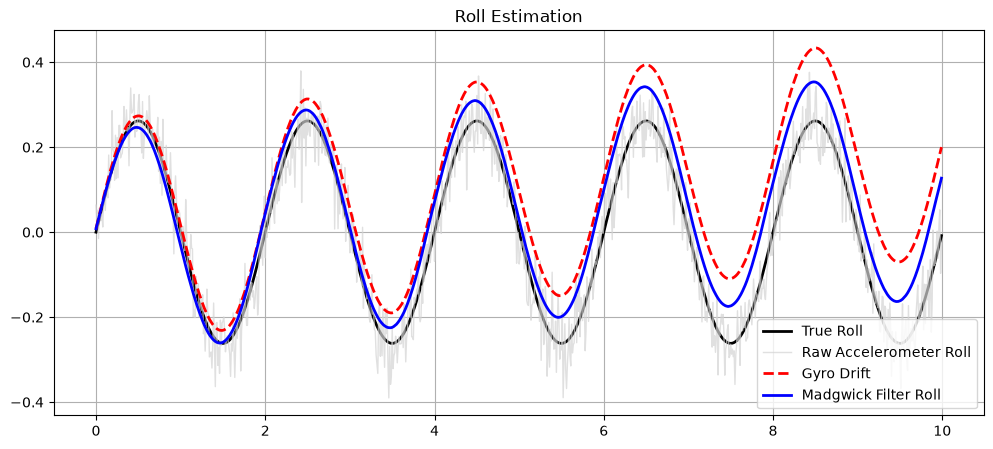

In [255]:
plt.figure(figsize=(12, 5))

plt.plot(t, real_roll, "k", linewidth=2, label="True Roll")
plt.plot(t, accel_roll_raw, color="lightgray", linewidth=1, alpha = 0.7, label="Raw Accelerometer Roll")
plt.plot(t, gyro_roll_integrated, "r--", linewidth=2, label="Gyro Drift")
plt.plot(t, roll_filtered, "b", linewidth=2, label="Madgwick Filter Roll")
plt.title ("Roll Estimation")
plt.legend(loc = 'lower right') 
plt.grid(True)
plt.show()

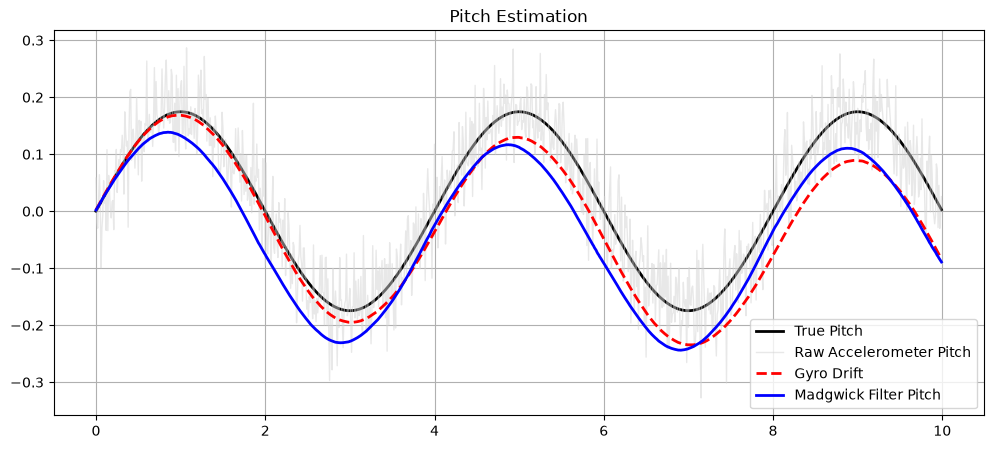

In [256]:
plt.figure(figsize=(12, 5))

plt.plot(t, real_pitch, "k", linewidth=2, label="True Pitch")
plt.plot(t, accel_pitch_raw, color="lightgray", linewidth=1, alpha = 0.5, label="Raw Accelerometer Pitch")
plt.plot(t, gyro_pitch_integrated, "r--", linewidth=2, label="Gyro Drift")
plt.plot(t, pitch_filtered, "b", linewidth=2, label="Madgwick Filter Pitch")

plt.title("Pitch Estimation")
plt.legend(loc = 'lower right')
plt.grid(True)
plt.show()

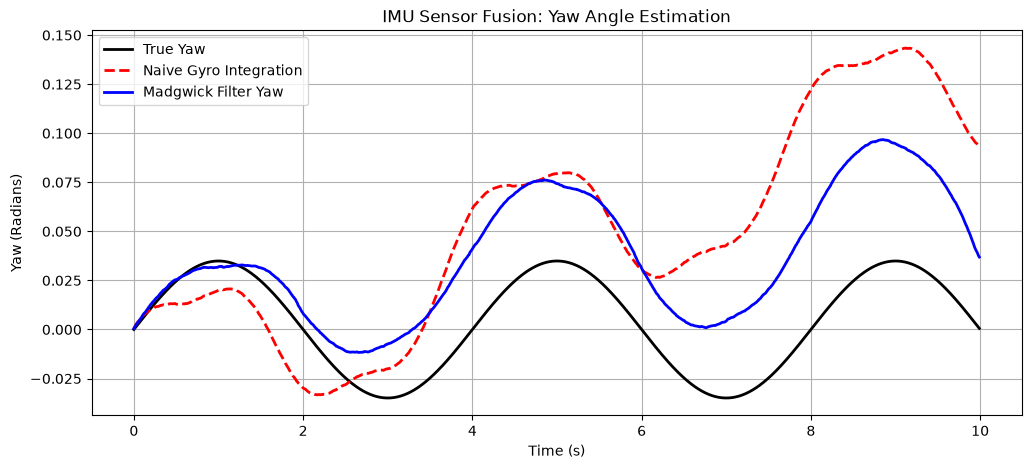

In [257]:
plt.figure(figsize=(12, 5))

plt.plot(t, np.unwrap(real_yaw), "k", linewidth=2, label="True Yaw")
plt.plot(t, np.unwrap(gyro_yaw_integrated), "r--", linewidth=2,
label="Naive Gyro Integration")
plt.plot(t, np.unwrap(yaw_filtered), "b", linewidth=2, label="Madgwick Filter Yaw")

plt.title("IMU Sensor Fusion: Yaw Angle Estimation")
plt.xlabel("Time (s)")
plt.ylabel("Yaw (Radians)")
plt.legend()
plt.grid(True)
plt.show()
